# Inverse Problem: Recovering $R/L_T$ from the Electrostatic Potential

We recover the temperature gradient scale length $R/L_T$ by matching the electrostatic potential $\phi(s, k_x, k_y)$ produced by a ground-truth linear simulation. The loss is the spectral energy mismatch between the predicted and target potentials, and exact gradients flow through all 400 RK4 time steps via `jax.grad`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import logging


os.environ["CUDA_VISIBLE_DEVICES"] = "4"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_gpu_enable_command_buffer="
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

import sys
sys.path.append("..")

In [15]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from matplotlib.ticker import ScalarFormatter, LogLocator, NullFormatter
from gyaradax import compute_geometry, GKParams, gk_init, gksolve
from gyaradax.solver import linear_precompute, default_state
from gyaradax.plot_utils import JAX_COLORS, SPECIES_COLORS

jax.config.update("jax_enable_x64", True)

## Geometry

Fixed circular equilibrium (CBC-like parameters). The geometry is computed once and stays outside the AD boundary.

In [ ]:
# geometry params (fixed, not optimized)
Q, SHAT, EPS = 1.4, 0.78, 0.19
NS, NKX, NKY, NVPAR, NMU = 16, 9, 8, 24, 8
KXMAX = 2.0 * NKX * SHAT  # approximate kxmax from shat and nkx

geometry = compute_geometry(
    q=Q, shat=SHAT, eps=EPS,
    ns=NS, nkx=NKX, nky=NKY, nvpar=NVPAR, nmu=NMU,
    vpar_max=3.0, nperiod=1, krhomax=1.4, kxmax=KXMAX,
)
ky = np.asarray(geometry["krho"])
print(f"grid: (nvpar={NVPAR}, nmu={NMU}, ns={NS}, nkx={NKX}, nky={NKY})")
print(f"ky range: [{ky[0]:.3f}, {ky[-1]:.3f}]")
print(f"kx range: [{float(geometry['kxrh'][0]):.3f}, {float(geometry['kxrh'][-1]):.3f}]")

## Ground truth

Run the solver at $R/L_T^\mathrm{true} = 6.9$ for 400 steps. The target is the final electrostatic potential $\phi^*(s, k_x, k_y)$.

In [5]:
# solver and physical parameters (shared across all runs)
DT = 0.01
NAVERAGE = 40
N_STEPS = 400
RLN = 2.22
DISP_PAR = 0.1
DISP_VP = 0.1
DISP_X = 0.1
DISP_Y = 0.1


def make_params(rlt_val):
    """build GKParams with the given rlt, pulling grid metadata from geometry."""
    return GKParams(
        dt=DT,
        naverage=NAVERAGE,
        rlt=rlt_val,
        rln=RLN,
        disp_par=DISP_PAR,
        disp_vp=DISP_VP,
        disp_x=DISP_X,
        disp_y=DISP_Y,
        non_linear=False,
        finit="cosine2",
        shat=SHAT,
        q=Q,
        eps=EPS,
        kthnorm=float(geometry["kthnorm"]),
        Rref=float(geometry["Rref"]),
        d2X=float(geometry["d2X"]),
        signB=float(geometry["signB"]),
        dvp=float(geometry["dvp"]),
        sgr_dist=float(geometry["sgr_dist"]),
        kxmax=float(geometry["kxmax"]),
        kymax=float(geometry["kymax"]),
    )

In [6]:
# ground truth
RLT_TRUE = 6.9

params_true = make_params(RLT_TRUE)
df_true, state_true = gk_init(geometry, params_true)
pre_true = linear_precompute(geometry, params_true)

t0 = time.time()
_, (phi_target, _), _ = gksolve(
    df_true, geometry, params_true, state_true, n_steps=N_STEPS, pre=pre_true
)
print(f"ground truth forward pass: {time.time() - t0:.1f}s")
print(f"phi_target shape: {phi_target.shape}")
print(f"phi_target spectral energy: {float(jnp.sum(jnp.abs(phi_target) ** 2)):.6e}")

ground truth forward pass: 3.7s
phi_target shape: (16, 9, 8)
phi_target spectral energy: 5.015180e+02


## Differentiable forward model

The loss is the mean spectral energy mismatch between predicted and target potentials:
$$\mathcal{L}(R/L_T) = \frac{1}{N} \sum_{s, k_x, k_y} |\phi(s,k_x,k_y;\, R/L_T) - \phi^*(s,k_x,k_y)|^2$$

`linear_precompute` is called inside the forward pass so that $R/L_T$-dependent drive coefficients are traced by AD.

In [7]:
def forward_phi(rlt_val):
    """run solver and return the final potential phi(s, kx, ky)."""
    params = make_params(rlt_val)
    df0, state0 = gk_init(geometry, params)
    pre = linear_precompute(geometry, params)
    _, (phi, _), _ = gksolve(df0, geometry, params, state0, n_steps=N_STEPS, pre=pre)
    return phi


def loss_fn(rlt_val):
    """spectral energy mismatch between predicted and target potential."""
    phi_pred = forward_phi(rlt_val)
    return jnp.mean(jnp.abs(phi_pred - phi_target) ** 2)


grad_fn = jax.jit(jax.grad(loss_fn))

# warmup: compile forward + backward
print("compiling forward + backward (first call)...")
t0 = time.time()
_ = loss_fn(jnp.array(1.0))
_ = grad_fn(jnp.array(1.0))
print(f"compilation done: {time.time() - t0:.1f}s")

compiling forward + backward (first call)...
compilation done: 11.2s


## Optimization

Recover $R/L_T$ starting from an initial guess of $10.0$ (true value of $6.9$).

In [8]:
RLT_INIT = 10.0
N_ITERS = 100
LR = 0.1

rlt = jnp.array(RLT_INIT)
optimizer = optax.adam(learning_rate=LR)
opt_state = optimizer.init(rlt)

history = {"rlt": [RLT_INIT], "loss": [], "grad": []}

pbar = tqdm(range(N_ITERS), desc="optimizing")
for i in pbar:
    loss_val = loss_fn(rlt)
    g = grad_fn(rlt)
    updates, opt_state = optimizer.update(g, opt_state)
    rlt = optax.apply_updates(rlt, updates)

    history["rlt"].append(float(rlt))
    history["loss"].append(float(loss_val))
    history["grad"].append(float(g))
    pbar.set_postfix(loss=f"{float(loss_val):.3e}", rlt=f"{float(rlt):.3f}", grad=f"{float(g):.2e}")

print(f"final rlt: {float(rlt):.4f} (true: {RLT_TRUE})")

SNAPSHOT_ITERS = [0, 5, 15, 30, N_ITERS]
phi_snapshots = {}
for it in SNAPSHOT_ITERS:
    phi_snapshots[it] = np.asarray(forward_phi(jnp.array(history["rlt"][it])))

optimizing:   0%|          | 0/100 [00:00<?, ?it/s]

final rlt: 6.9079 (true: 6.9)


## Results: convergence and potential comparison

In [9]:
kx = np.asarray(geometry["kxrh"])
sgrid = np.asarray(geometry["sgrid"])

phi_init = phi_snapshots[0]
phi_final = phi_snapshots[N_ITERS]
phi_tgt = np.asarray(phi_target)

ky_energy = np.sum(np.abs(phi_tgt) ** 2, axis=(0, 1))
iy_dom = int(np.argmax(ky_energy[1:])) + 1
print(f"dominant ky mode: iy={iy_dom}, ky={ky[iy_dom]:.3f}")

def ky_spectrum(phi):
    return np.sum(np.abs(phi) ** 2, axis=(0, 1))

dominant ky mode: iy=4, ky=0.819


## Paper figure: convergence + spectra

Three panels at equal aspect ratio: (a) loss convergence, (b) parameter trajectory, (c) $k_y$ spectral energy comparison.

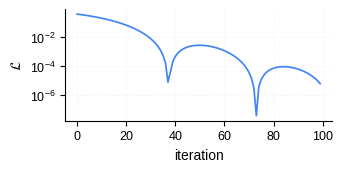

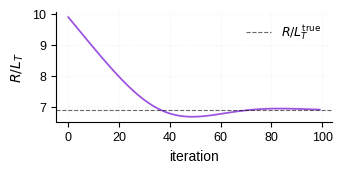

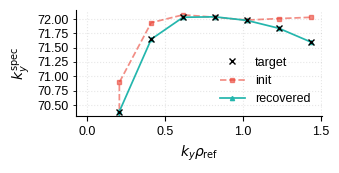

In [ ]:
fig, ax = plt.subplots(figsize=(3.5, 2.0))
ax.semilogy(history["loss"], color=JAX_COLORS["blue"])
ax.set_xlabel("iteration")
ax.set_ylabel(r"$\mathcal{L}$")
ax.grid(True, which="both")
fig.tight_layout()
fig.savefig("figs/inverse_loss.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(3.5, 2.0))
ax.plot(history["rlt"][1:], color=JAX_COLORS["purple"])
ax.axhline(RLT_TRUE, color="k", ls="--", lw=0.8, alpha=0.6,
           label=f"$R/L_T^{{\\mathrm{{true}}}}$")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$R/L_T$")
ax.legend(frameon=False)
ax.grid(True)
fig.tight_layout()
fig.savefig("figs/inverse_param.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(3.5, 2.0))
ax.plot(ky, ky_spectrum(phi_tgt), "kx", ms=5, label="target", zorder=3)
ax.plot(ky, ky_spectrum(phi_init), "s--", ms=3, color=JAX_COLORS["red"],
        alpha=0.6, label="init")
ax.plot(ky, ky_spectrum(phi_final), "^-", ms=3, color=JAX_COLORS["cyan"],
        label="recovered")

ax.set_yscale("log")
ax.set_xlabel(r"$k_y \rho_\mathrm{ref}$")
ax.set_ylabel(r"$k_y^{\text{spec}}$")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.3)

ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=4))

y_formatter = ScalarFormatter()
y_formatter.set_scientific(False)
y_formatter.set_useOffset(False)

ax.yaxis.set_major_formatter(y_formatter)
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.get_minor_formatter().set_scientific(False)

fig.tight_layout()
fig.savefig("figs/inverse_spectrum.pdf")

## Loss landscape and optimizer trajectory

In [11]:
rlt_grid = np.linspace(2.0, 12.0, 40)
loss_landscape = []
grad_landscape = []

for r in tqdm(rlt_grid):
    l = float(loss_fn(jnp.array(r)))
    g = float(grad_fn(jnp.array(r)))
    loss_landscape.append(l)
    grad_landscape.append(g)

loss_landscape = np.array(loss_landscape)
grad_landscape = np.array(grad_landscape)

  0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipykernel_2743278/2508111346.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


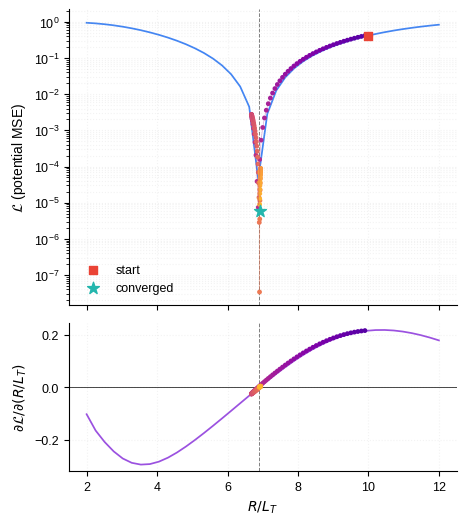

In [21]:
opt_rlt = np.array(history["rlt"][1:])
opt_loss = np.array(history["loss"])
opt_grad = np.array(history["grad"])
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(opt_rlt)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5.0, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

# top: loss landscape + optimizer path
ax1.plot(rlt_grid, loss_landscape, color=JAX_COLORS["blue"], zorder=1)
ax1.axvline(RLT_TRUE, color="k", ls="--", lw=0.7, alpha=0.5)
ax1.scatter(opt_rlt, opt_loss, c=colors, s=12, zorder=3, edgecolors="none")
for i in range(len(opt_rlt) - 1):
    ax1.annotate(
        "", xy=(opt_rlt[i + 1], opt_loss[i + 1]),
        xytext=(opt_rlt[i], opt_loss[i]),
        arrowprops=dict(arrowstyle="-", color=colors[i], lw=0.5, alpha=0.4),
    )
ax1.scatter([RLT_INIT], [opt_loss[0]], marker="s", s=40, color=JAX_COLORS["red"],
            zorder=4, label="start")
ax1.scatter([opt_rlt[-1]], [opt_loss[-1]], marker="*", s=80, color=JAX_COLORS["cyan"],
            zorder=4, label="converged")
ax1.set_ylabel(r"$\mathcal{L}$ (potential MSE)")
ax1.set_yscale("log")
ax1.legend(frameon=False)
ax1.grid(True, which="both")

# bottom: gradient landscape
ax2.plot(rlt_grid, grad_landscape, color=JAX_COLORS["purple"], zorder=1)
ax2.axhline(0, color="k", lw=0.5)
ax2.axvline(RLT_TRUE, color="k", ls="--", lw=0.7, alpha=0.5)
ax2.scatter(opt_rlt, opt_grad, c=colors, s=12, zorder=3, edgecolors="none")
ax2.set_xlabel(r"$R/L_T$")
ax2.set_ylabel(r"$\partial \mathcal{L} / \partial (R/L_T)$")
ax2.grid(True)

fig.tight_layout()
fig.savefig("figs/inv_landscape.pdf")